Get pigment concentrations
Compare to MOANA

In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

lon_range = (-30, -10)

lat_range = (30, 50)

time_range = ("2025-09-01", "2025-09-10")

RRS
- 0.04 degree
- L3 Browser search only returns 5 distinct nm bands; requires API access / collection specification

SST: L3 Browser Search AQUA MODIS (11 micrometer)
- 0.04 degree
- For some reason one day is just missing(?); shouldn't matter too much, since Dr. Kramer's code takes the mean if multiple filepaths are passed in anyways

SSS: https://podaac.jpl.nasa.gov/dataset/SMAP_JPL_L3_SSS_CAP_8DAY-RUNNINGMEAN_V5#
- 0.25 degree

---

Obtain pigment concentrations in mg/m^3 for each cell/grid point
- Currently the code automatically interpolates to rrs resolution
- Can adjust to use the maximum resolution between RRS/SST/SSS

In [ ]:
from pathlib import Path

output_path = Path("../../data/outputs/initial_test/sdp_results.nc")

pigment_ds = xr.open_dataset(output_path)
pigment_ds


<xarray.Dataset> Size: 23MB
Dimensions:    (lat: 474, lon: 474)
Coordinates:
  * lat        (lat) float32 2kB 30.15 30.19 30.23 30.27 ... 49.77 49.81 49.85
  * lon        (lon) float32 2kB -29.85 -29.81 -29.77 ... -10.23 -10.19 -10.15
Data variables: (12/13)
    t_chla     (lat, lon) float64 2MB ...
    zea        (lat, lon) float64 2MB ...
    dv_chla    (lat, lon) float64 2MB ...
    butfuco    (lat, lon) float64 2MB ...
    hexfuco    (lat, lon) float64 2MB ...
    allo       (lat, lon) float64 2MB ...
    ...         ...
    neo        (lat, lon) float64 2MB ...
    viola      (lat, lon) float64 2MB ...
    fuco       (lat, lon) float64 2MB ...
    chl_c1_c2  (lat, lon) float64 2MB ...
    chl_c3     (lat, lon) float64 2MB ...
    perid      (lat, lon) float64 2MB ...

Diatoms: Identified by the biomarker pigment fucoxanthin (Fuco)

Dinoflagellates: Identified by peridinin (Perid)

Haptophytes: Identified by 19′-hexanoyloxyfucoxanthin (HexFuco)

Green algae: Identified by monovinyl chlorophyll b (MVchlb)

Cyanobacteria: Identified by zeaxanthin (Zea)

In [4]:
import numpy as np
import pandas as pd

stats_records = []
for var in pigment_ds.data_vars:
    da = pigment_ds[var].where(np.isfinite(pigment_ds[var]))
    stats_records.append(
        {
            "pigment": var,
            "min": float(da.min()),
            "median": float(da.median()),
            "max": float(da.max()),
            "mean": float(da.mean()),
            "std": float(da.std()),
        }
    )

pd.DataFrame(stats_records).set_index("pigment").round(4)


,min,median,max,mean,std
pigment,,,,,
t_chla,0.0,0.6517,2.8844,0.6165,0.2944
zea,0.0,0.0520,0.2077,0.0506,0.0160
dv_chla,0.0,0.0000,0.1191,0.0014,0.0049
butfuco,0.0,0.0593,0.1526,0.0576,0.0136
hexfuco,0.0,0.2067,0.5784,0.1976,0.0535
allo,0.0,0.0254,0.1215,0.0236,0.0100
mv_chlb,0.0,0.0875,0.3138,0.0822,0.0315
neo,0.0,0.0079,0.0486,0.0073,0.0043
viola,0.0,0.0156,0.0579,0.0143,0.0062


---
Distribution of pigments relative to their own min/max value

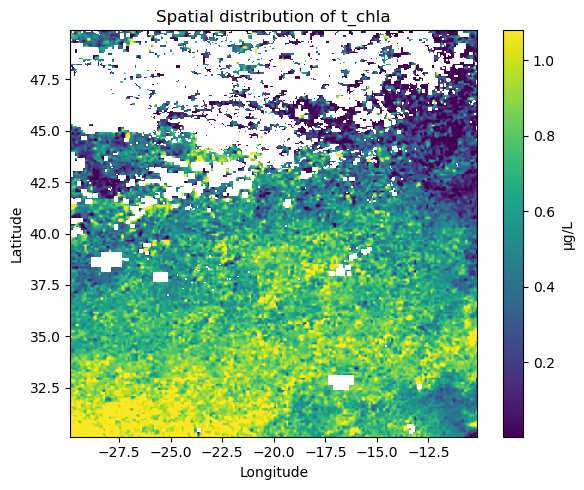

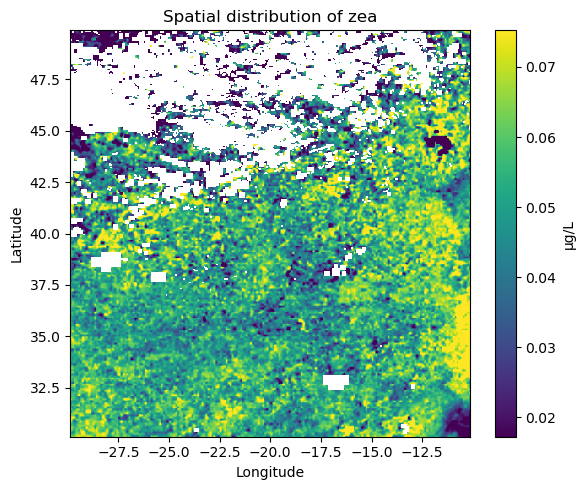

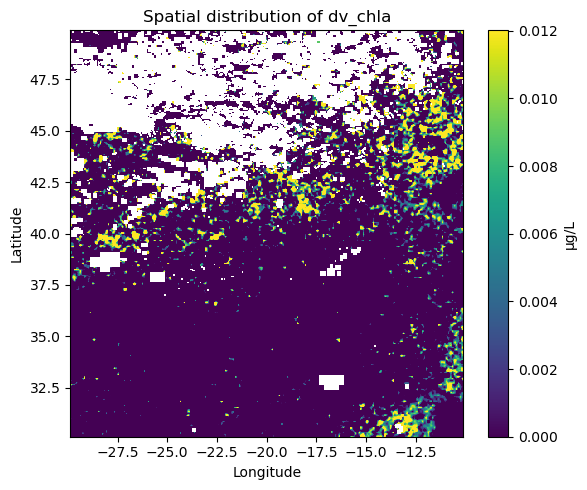

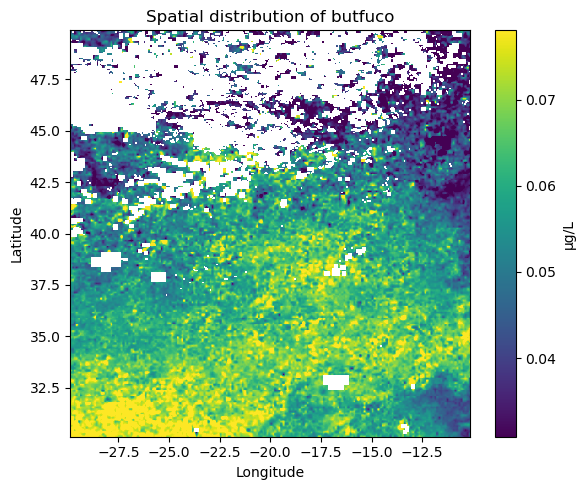

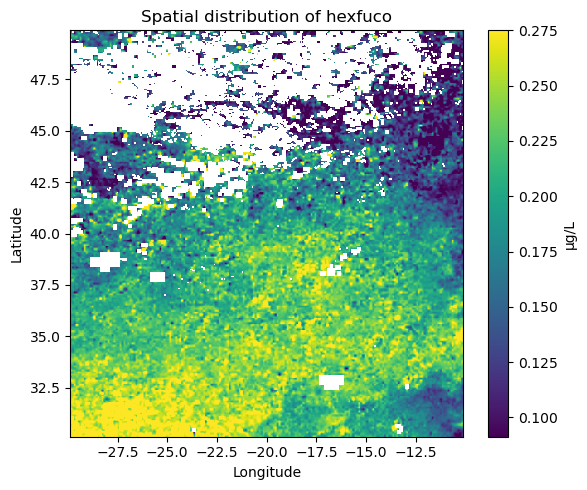

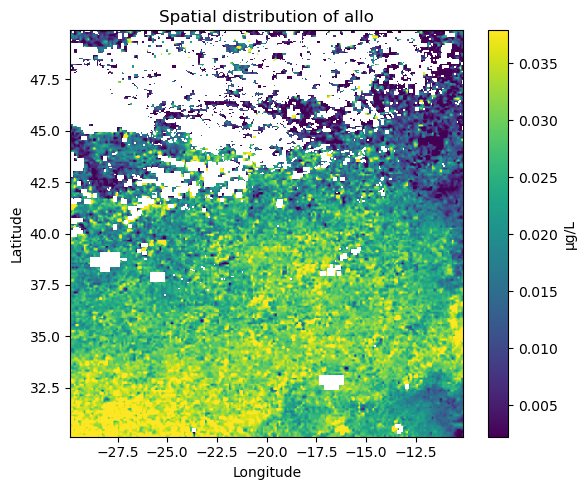

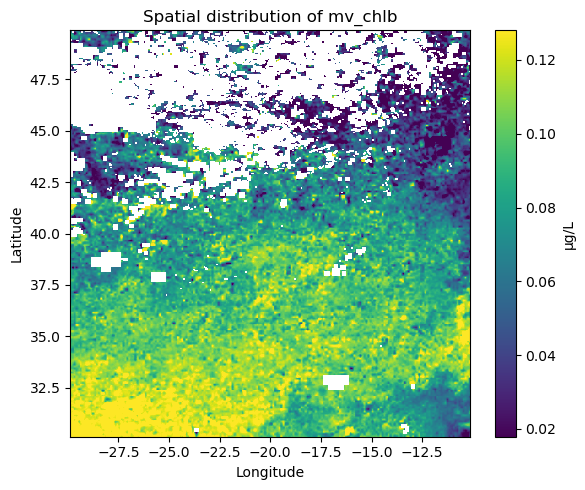

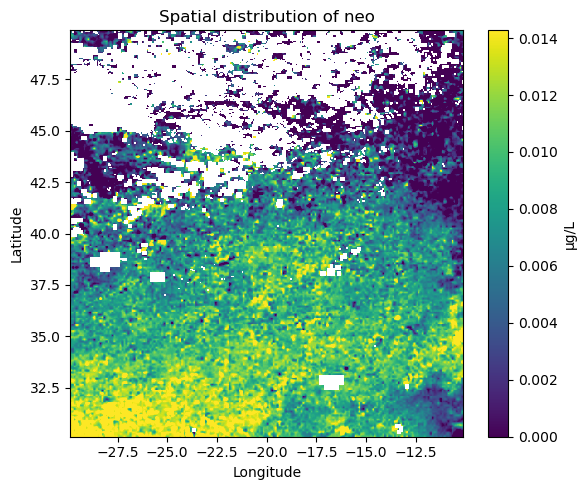

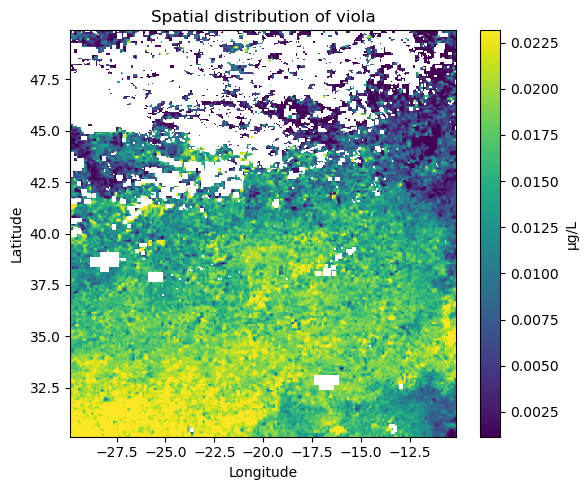

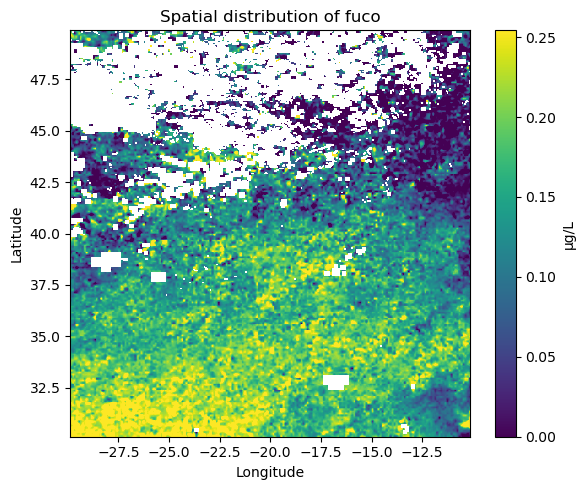

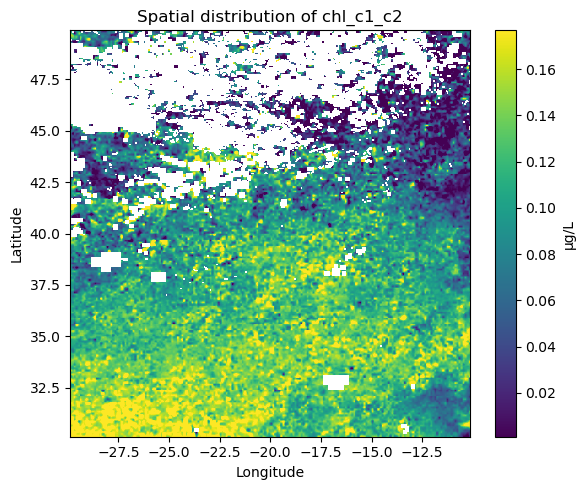

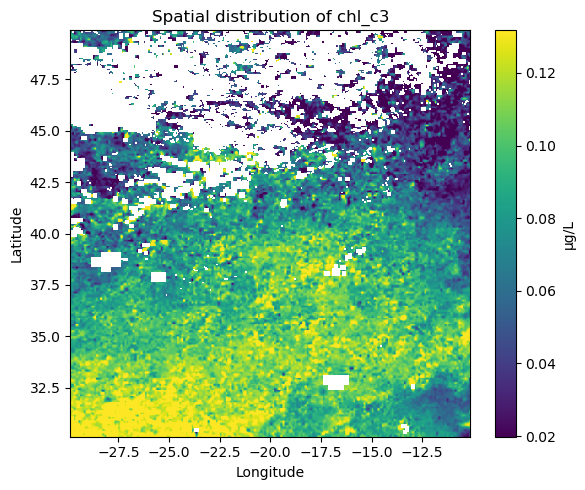

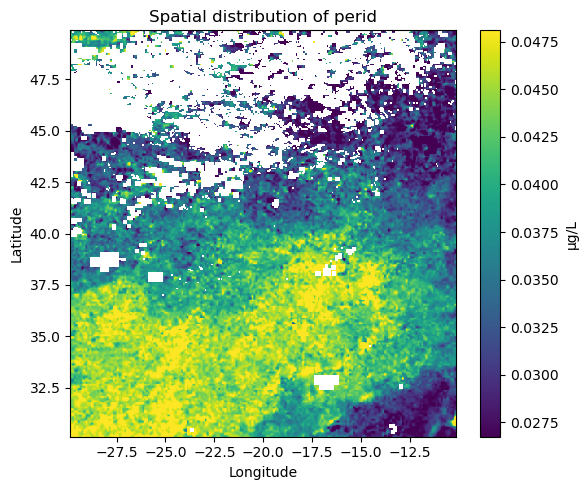

In [5]:
# Loop through all pigments in the dataset
for pigment_name in pigment_ds.data_vars:
    da = pigment_ds[pigment_name]
    
    vmin, vmax = np.nanpercentile(da.values, [4, 96])
    
    fig, ax = plt.subplots(figsize=(6, 5))
    mesh = ax.pcolormesh(
        da["lon"],
        da["lat"],
        da,
        cmap="viridis",
        shading="auto",
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_title(f"Spatial distribution of {pigment_name}")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    fig.colorbar(mesh, ax=ax, label="µg/L")
    fig.tight_layout()
    plt.show()
    plt.close(fig)


---
Distribution with color scale that is more fixed

Global color scale: vmin=0.0000, vmax=0.2217


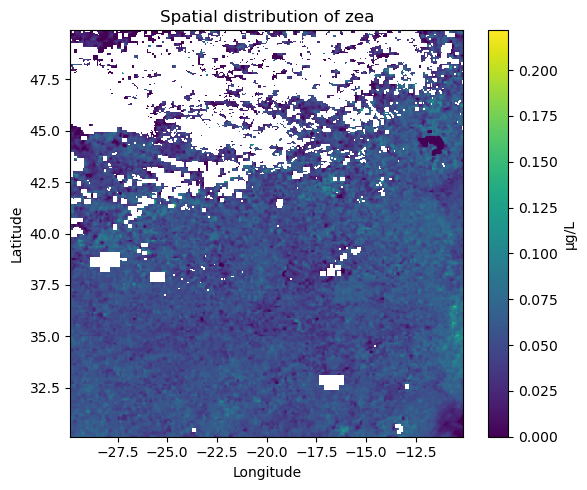

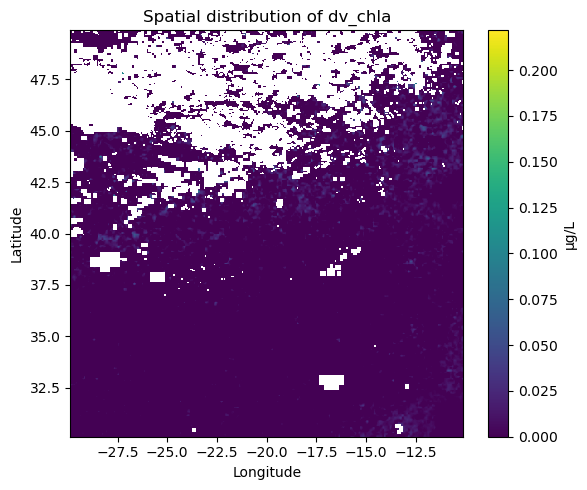

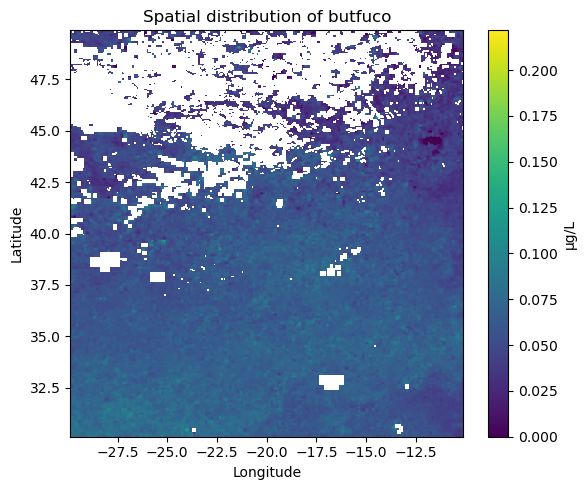

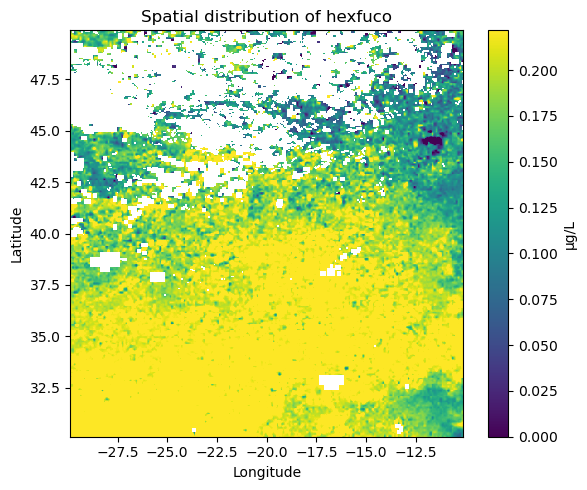

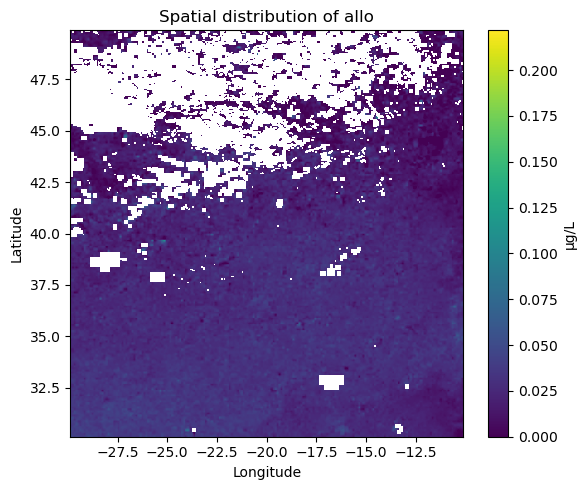

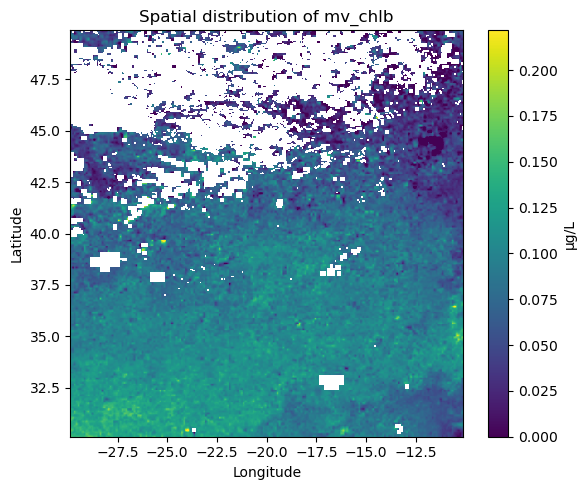

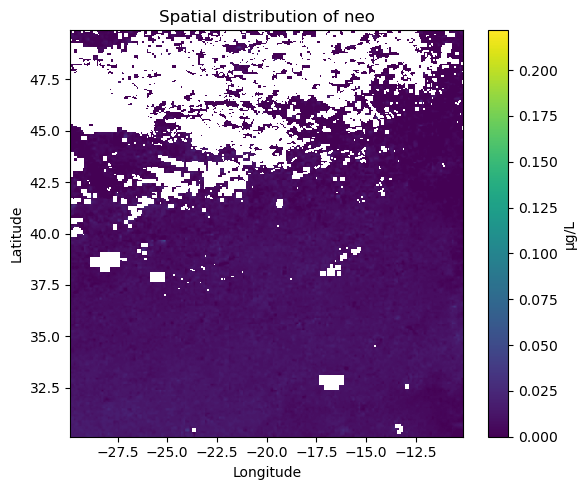

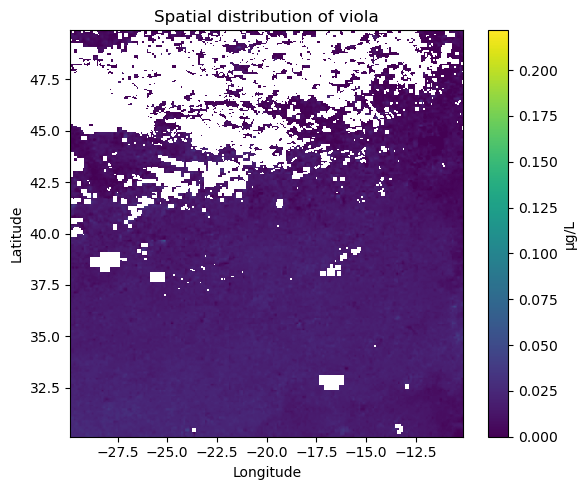

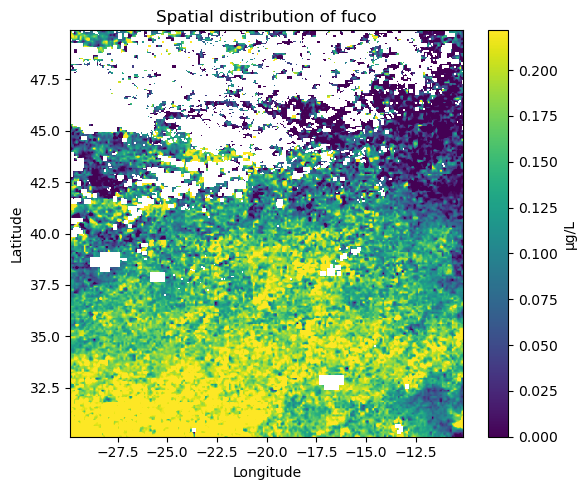

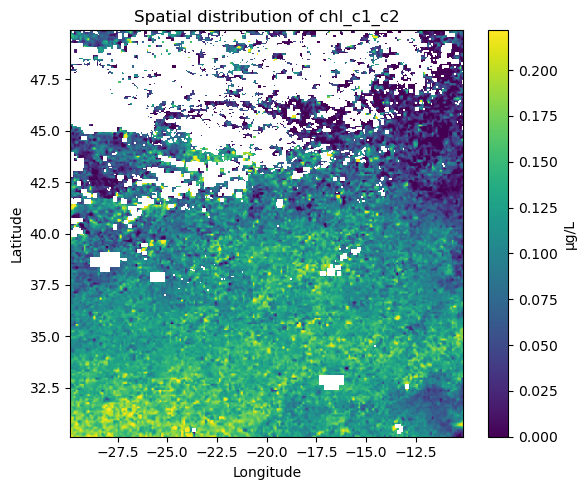

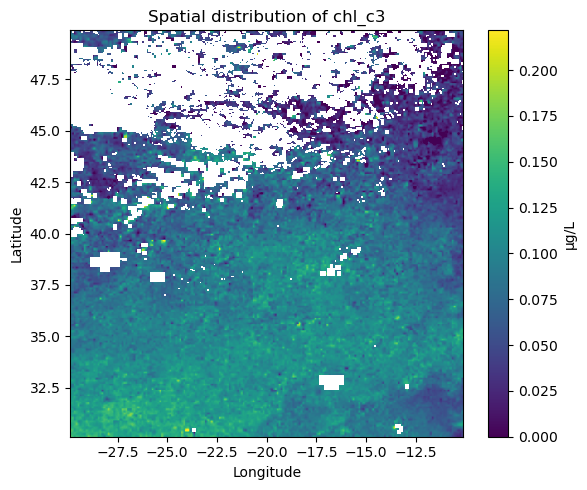

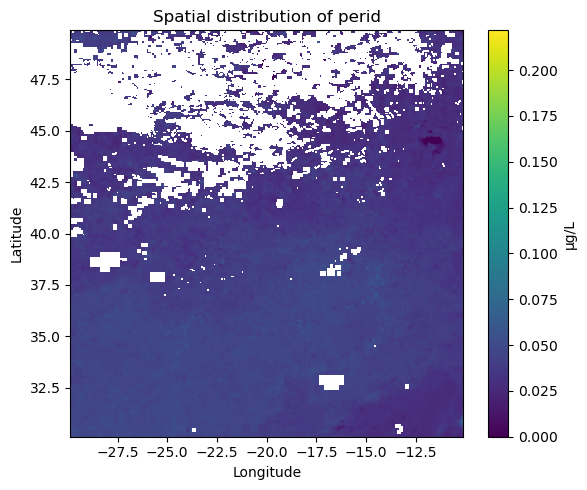

In [6]:
# Calculate global min/max across all pigments using percentiles (excluding total chlorophyll)
all_values = []
for pigment_name in pigment_ds.data_vars:
    if pigment_name == "t_chla":  # Exclude total chlorophyll
        continue
    da = pigment_ds[pigment_name]
    valid_values = da.values[np.isfinite(da.values)]
    all_values.extend(valid_values.flatten())

# Use 4th and 96th percentiles for global color scale
global_vmin, global_vmax = np.nanpercentile(all_values, [4, 96])

print(f"Global color scale: vmin={global_vmin:.4f}, vmax={global_vmax:.4f}")

# Loop through all pigments using the same global color scale (excluding total chlorophyll)
for pigment_name in pigment_ds.data_vars:
    if pigment_name == "t_chla":  # Exclude total chlorophyll
        continue
    da = pigment_ds[pigment_name]
    
    fig, ax = plt.subplots(figsize=(6, 5))
    mesh = ax.pcolormesh(
        da["lon"],
        da["lat"],
        da,
        cmap="viridis",
        shading="auto",
        vmin=global_vmin,
        vmax=global_vmax,
    )
    ax.set_title(f"Spatial distribution of {pigment_name}")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    fig.colorbar(mesh, ax=ax, label="µg/L")
    fig.tight_layout()
    plt.show()
    plt.close(fig)


---
Color map based on dominant pigment

/var/folders/s0/zq5m1f7578s12jw_8klt90dm0000gn/T/ipykernel_2189/410127186.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab20')(np.linspace(0, 1, n_pigments))


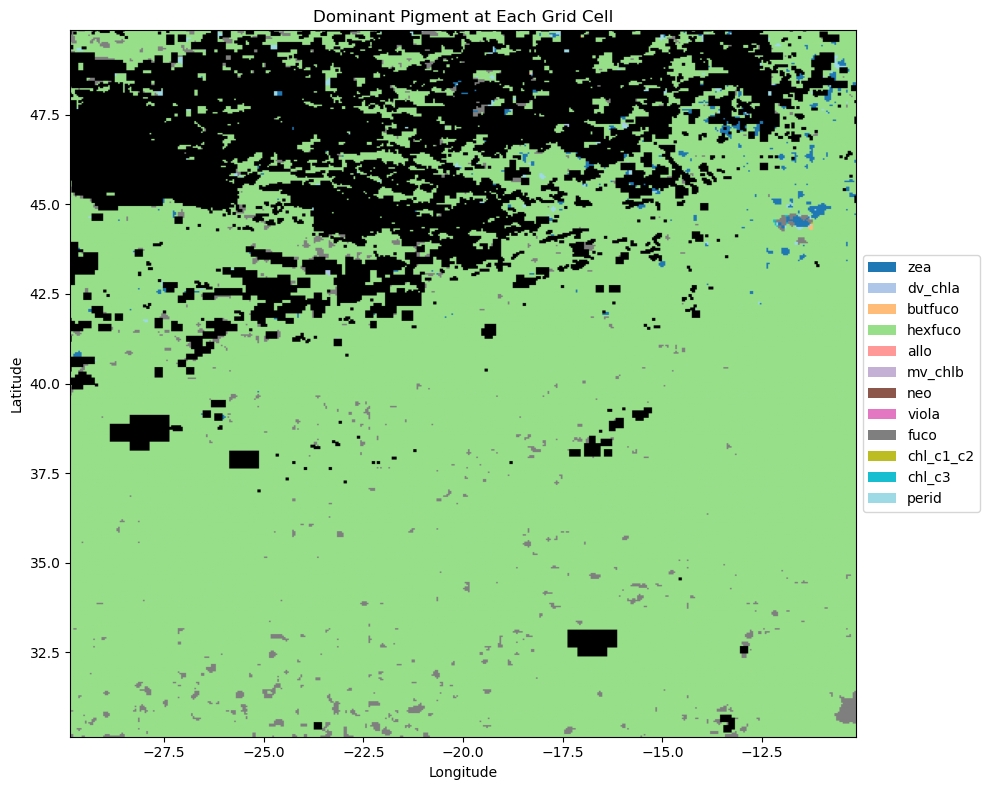

In [ ]:


accessory_pigments = [name for name in pigment_ds.data_vars if name != "t_chla"]
n_pigments = len(accessory_pigments)

colors = cm.get_cmap('tab20')(np.linspace(0, 1, n_pigments))
pigment_colors = dict(zip(accessory_pigments, colors))

pigment_stack = []
for pigment_name in accessory_pigments:
    da = pigment_ds[pigment_name]
    pigment_stack.append(da.values)

pigment_array = np.stack(pigment_stack, axis=0)

# Check which cells have at least one valid pigment
valid_mask = np.isfinite(pigment_array).any(axis=0)

# Replace NaN with -inf so argmax will ignore them and pick valid values
# This allows cells with some valid pigments to correctly identify the dominant one
pigment_array_for_argmax = pigment_array.copy()
pigment_array_for_argmax[~np.isfinite(pigment_array_for_argmax)] = -np.inf

# Find dominant pigment index (will pick valid values over -inf)
dominant_indices = np.argmax(pigment_array_for_argmax, axis=0)

lat_size, lon_size = dominant_indices.shape
color_map = np.zeros((lat_size, lon_size, 4))

# Color valid cells based on dominant pigment
for i, pigment_name in enumerate(accessory_pigments):
    mask = (dominant_indices == i) & valid_mask
    color_map[mask] = pigment_colors[pigment_name]

# Set invalid cells (no valid pigments) to black
color_map[~valid_mask] = [0, 0, 0, 1]

da_example = pigment_ds[accessory_pigments[0]]
lon_coords = da_example["lon"].values
lat_coords = da_example["lat"].values

fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(color_map, extent=(lon_coords.min(), lon_coords.max(), 
                              lat_coords.min(), lat_coords.max()), 
          aspect='auto', origin='lower')
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Dominant Pigment at Each Grid Cell")

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=pigment_colors[name], label=name) 
                   for name in accessory_pigments]
ax.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5))

fig.tight_layout()
plt.show()
plt.close(fig)
